Adjectives hclustering with limiting the number of occurrences - not eliminating those part of idioms

In [3]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

connected to port: 61994


In [4]:
path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
grewpy.set_config('ud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

In [6]:
all_matches = corpus.search(grewpy.Request("pattern{X[upos=ADJ]}"), clustering_parameter=['X.lemma'])

In [7]:
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value

In [8]:
with open("../3. probability_matrix/patterns_adj.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [9]:
data = { k : list() for k in matches }
for adv, mts in matches.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

unique_adv = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, matches in data.items() for m in matches for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_adv) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(matches)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = X[adv2idx[adv]] / n_samples
print(f"{X.shape=}")

X.shape=(403, 227)


In [22]:
unique_features

['node:X:child:Definite=Def',
 'node:X:child:Definite=Ind',
 'node:X:child:Emph=No',
 'node:X:child:Emph=Yes',
 'node:X:child:ExtPos=ADJ',
 'node:X:child:ExtPos=ADP',
 'node:X:child:ExtPos=ADV',
 'node:X:child:ExtPos=CCONJ',
 'node:X:child:ExtPos=NOUN',
 'node:X:child:ExtPos=PRON',
 'node:X:child:ExtPos=PROPN',
 'node:X:child:ExtPos=SCONJ',
 'node:X:child:Foreign=Yes',
 'node:X:child:Gender=Fem',
 'node:X:child:Gender=Masc',
 'node:X:child:InTitle=Yes',
 'node:X:child:Lang=en',
 'node:X:child:Mood=Cnd',
 'node:X:child:Mood=Imp',
 'node:X:child:Mood=Ind',
 'node:X:child:Mood=Sub',
 'node:X:child:NumType=Ord',
 'node:X:child:Number=Plur',
 'node:X:child:Number=Sing',
 'node:X:child:Number__psor=Plur',
 'node:X:child:Number__psor=Sing',
 'node:X:child:Person=1',
 'node:X:child:Person=2',
 'node:X:child:Person=3',
 'node:X:child:Person__psor=1',
 'node:X:child:Person__psor=3',
 'node:X:child:Polarity=Neg',
 'node:X:child:Poss=Yes',
 'node:X:child:PronType=Art',
 'node:X:child:PronType=Dem'

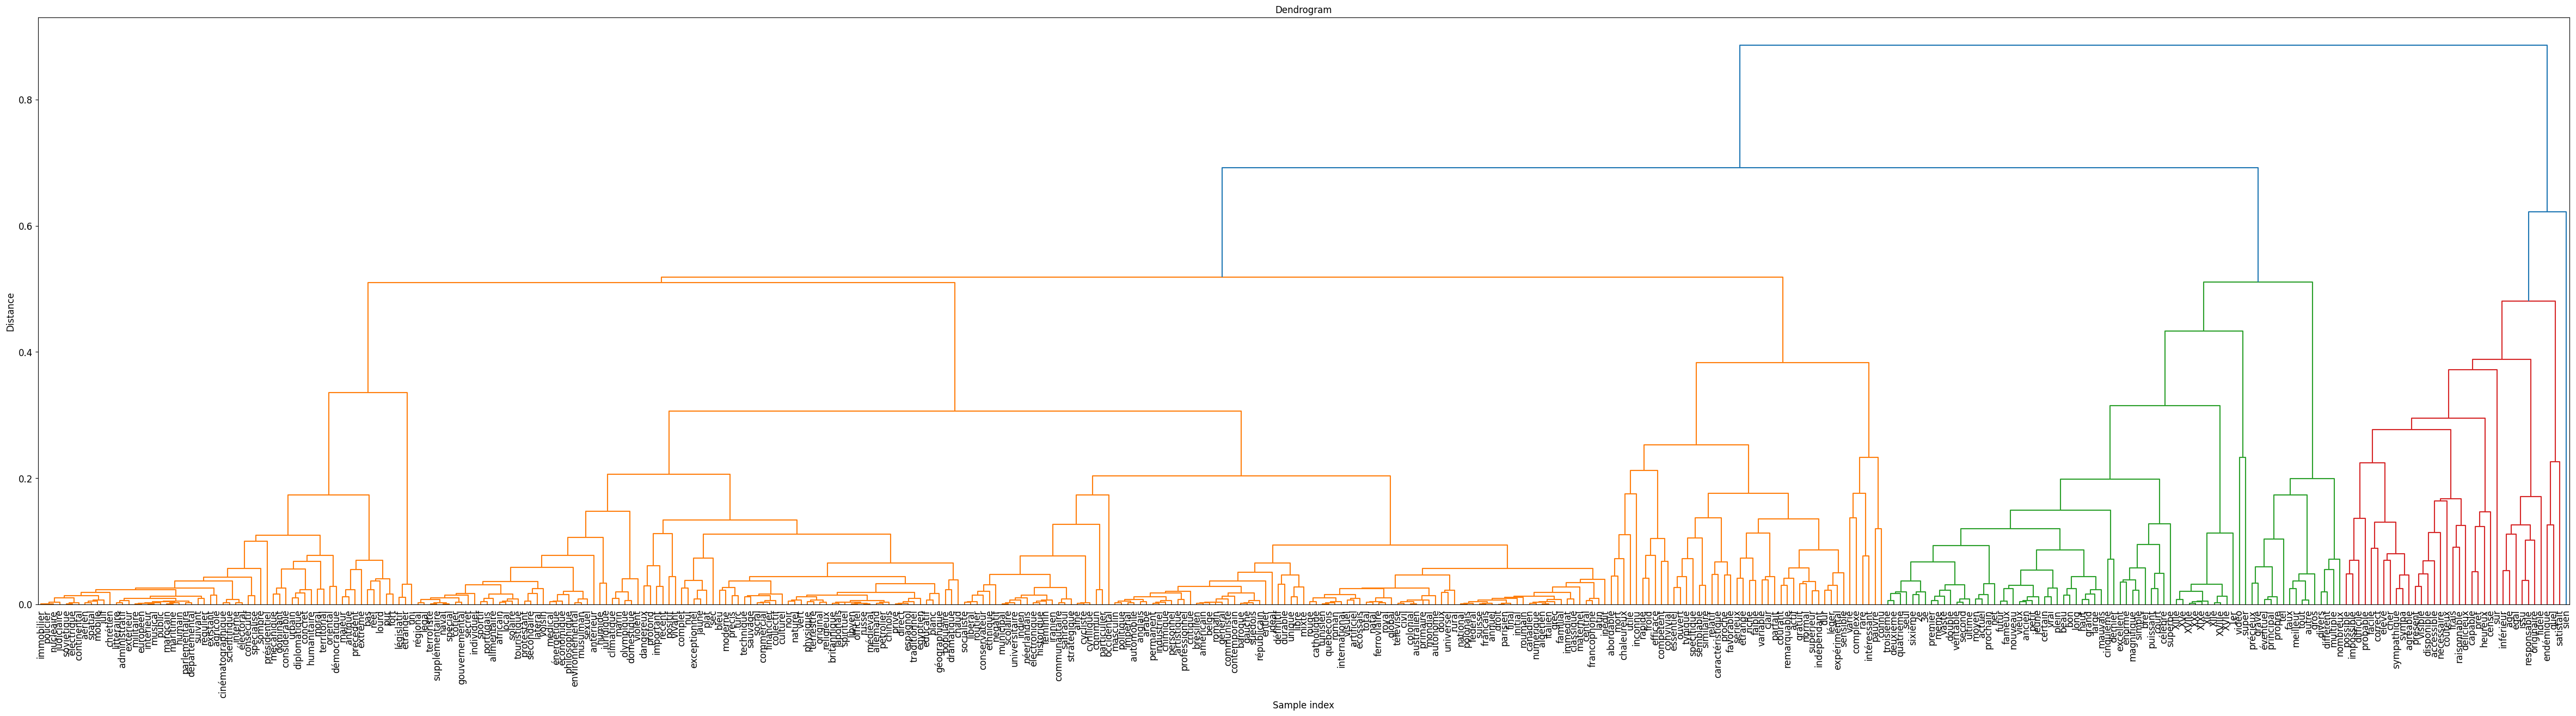

In [10]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
import matplotlib.pyplot as plt

# Hamming or jacard for categorical data, cosine for sparse matrices (normally used in NLP)
# I compute the distance for each pair of lines, each POS
distance_matrix = pdist(X, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)

plt.figure(figsize=(60, 14))

dn = dendrogram(linked,
                orientation='top',
                labels=[name for name in unique_adv],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

In [11]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

def find_optimal_clusters(X, max_clusters=20, metric='cosine', method='complete'):
    distance_matrix = pdist(X, metric=metric)
    linked = linkage(distance_matrix, method=method, optimal_ordering=True)
    
    silhouette_scores = []
    for num_clusters in range(2, max_clusters + 1):
        labels = fcluster(linked, num_clusters, criterion='maxclust')
        if len(np.unique(labels)) > 1:  # Ensure there is more than one cluster
            score = silhouette_score(X, labels, metric=metric)
            silhouette_scores.append(score)
            print(f'Number of clusters: {num_clusters}, Silhouette Score: {score}')
        else:
            silhouette_scores.append(-1)  # Append a low score if only one cluster
    
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2
    return optimal_clusters, silhouette_scores

# Find the optimal number of clusters
optimal_clusters, silhouette_scores = find_optimal_clusters(X, max_clusters=50)
print(f'Optimal number of clusters: {optimal_clusters}')
print(X.shape)

Number of clusters: 2, Silhouette Score: 0.6307232671229585
Number of clusters: 3, Silhouette Score: 0.5038075426593748
Number of clusters: 4, Silhouette Score: 0.5032769185188959
Number of clusters: 5, Silhouette Score: 0.4799619988441354
Number of clusters: 6, Silhouette Score: 0.47011989686679817
Number of clusters: 7, Silhouette Score: 0.23350978156299412
Number of clusters: 8, Silhouette Score: 0.22751522678914346
Number of clusters: 9, Silhouette Score: 0.23369297241834638
Number of clusters: 10, Silhouette Score: 0.23593144398111507
Number of clusters: 11, Silhouette Score: 0.2421232227213593
Number of clusters: 12, Silhouette Score: 0.2435606233335395
Number of clusters: 13, Silhouette Score: 0.21132264551291727
Number of clusters: 14, Silhouette Score: 0.22327273043802826
Number of clusters: 15, Silhouette Score: 0.24567431088727218
Number of clusters: 16, Silhouette Score: 0.2488670705407357
Number of clusters: 17, Silhouette Score: 0.24805039620906633
Number of clusters: 18,

In [12]:
# see what there is in each cluster
labels = fcluster(linked, optimal_clusters, criterion='maxclust')
clusters = {i: [] for i in range(1, optimal_clusters + 1)}
for i, label in enumerate(labels):
    clusters[label].append(i)

for cluster, members in clusters.items():
    print(f'Cluster {cluster}:')
    for member in members:
        print(f'  {unique_adv[member]}')

Cluster 1:
  accessible
  agréable
  capable
  censé
  cher
  correct
  coûteux
  difficile
  disponible
  délicieux
  endémique
  facile
  fidèle
  frais
  heureux
  impossible
  inférieur
  issu
  nécessaire
  originaire
  possible
  probable
  présent
  prêt
  quel
  raisonnable
  responsable
  satisfait
  sien
  sympa
  sympathique
  sûr
  visible
  âgé
  égal
  élevé
Cluster 2:
  1er
  2e
  3e
  XIIIe
  XIIe
  XIXe
  XIe
  XVIIIe
  XVIIe
  XVIe
  XVe
  XXe
  abordable
  actif
  actuel
  administratif
  africain
  agricole
  algérien
  alimentaire
  allemand
  américain
  ancien
  anglais
  annuel
  antique
  antérieur
  arabe
  artificiel
  artistique
  australien
  automobile
  autonome
  autre
  aérien
  aîné
  baroque
  bas
  beau
  belge
  blanc
  bleu
  bon
  bref
  britannique
  brésilien
  canadien
  caractéristique
  catholique
  central
  certain
  chaleureux
  chaud
  chimique
  chinois
  chrétien
  cinquième
  cinématographique
  civil
  clair
  classique
  climatique
 

In [13]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for Plotly
df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': labels,
    'Word': unique_adv
})
# pca1_min, pca1_max = df['PCA1'].min(), df['PCA1'].max()
# pca2_min, pca2_max = df['PCA2'].min(), df['PCA2'].max()
# Create a scatter plot with Plotly
fig = go.Figure()

# Add traces for each cluster
for cluster in range(1, optimal_clusters + 1):
    cluster_data = df[df['Cluster'] == cluster]
    fig.add_trace(go.Scatter(
        x=cluster_data['PCA1'],
        y=cluster_data['PCA2'],
        mode='markers',
        marker=dict(size=10),
        name=f'Cluster {cluster}',
        text=cluster_data['Word'],
        hoverinfo='text'
    ))

# Update layout with dropdown menu
fig.update_layout(
    title='Word Clusters',
    xaxis_title='PCA1',
    yaxis_title='PCA2',
    # xaxis=dict(range=[pca1_min, pca1_max]),
    # yaxis=dict(range=[pca2_min, pca2_max]),
    updatemenus=[
        {
            'buttons': [
                {
                    'label': 'All Clusters',
                    'method': 'update',
                    'args': [{'visible': [True] * optimal_clusters},
                             {'title': 'All Clusters'}]
                }
            ] + [
                {
                    'label': f'Cluster {i}',
                    'method': 'update',
                    'args': [{'visible': [j == i - 1 for j in range(optimal_clusters)]},
                             {'title': f'Cluster {i}'}]
                } for i in range(1, optimal_clusters + 1)
            ],
            'direction': 'down',
            'showactive': True
        }
    ]
)

fig.show()

# If we also remove those that are part of an idiom

Like en general, de nouveau

In [23]:
all_matches = corpus.search(grewpy.Request("pattern{X[upos=ADJ]}").without("X[InIdiom]").without("X[Idiom]"), clustering_parameter=['X.lemma'])

In [24]:
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value

In [25]:
with open("patterns_adj_no_idioms.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [26]:
data = { k : list() for k in matches }
for adv, mts in matches.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

In [27]:
unique_adv = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, matches in data.items() for m in matches for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_adv) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [28]:
X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(matches)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = X[adv2idx[adv]] / n_samples
print(f"{X.shape=}")

X.shape=(403, 350)


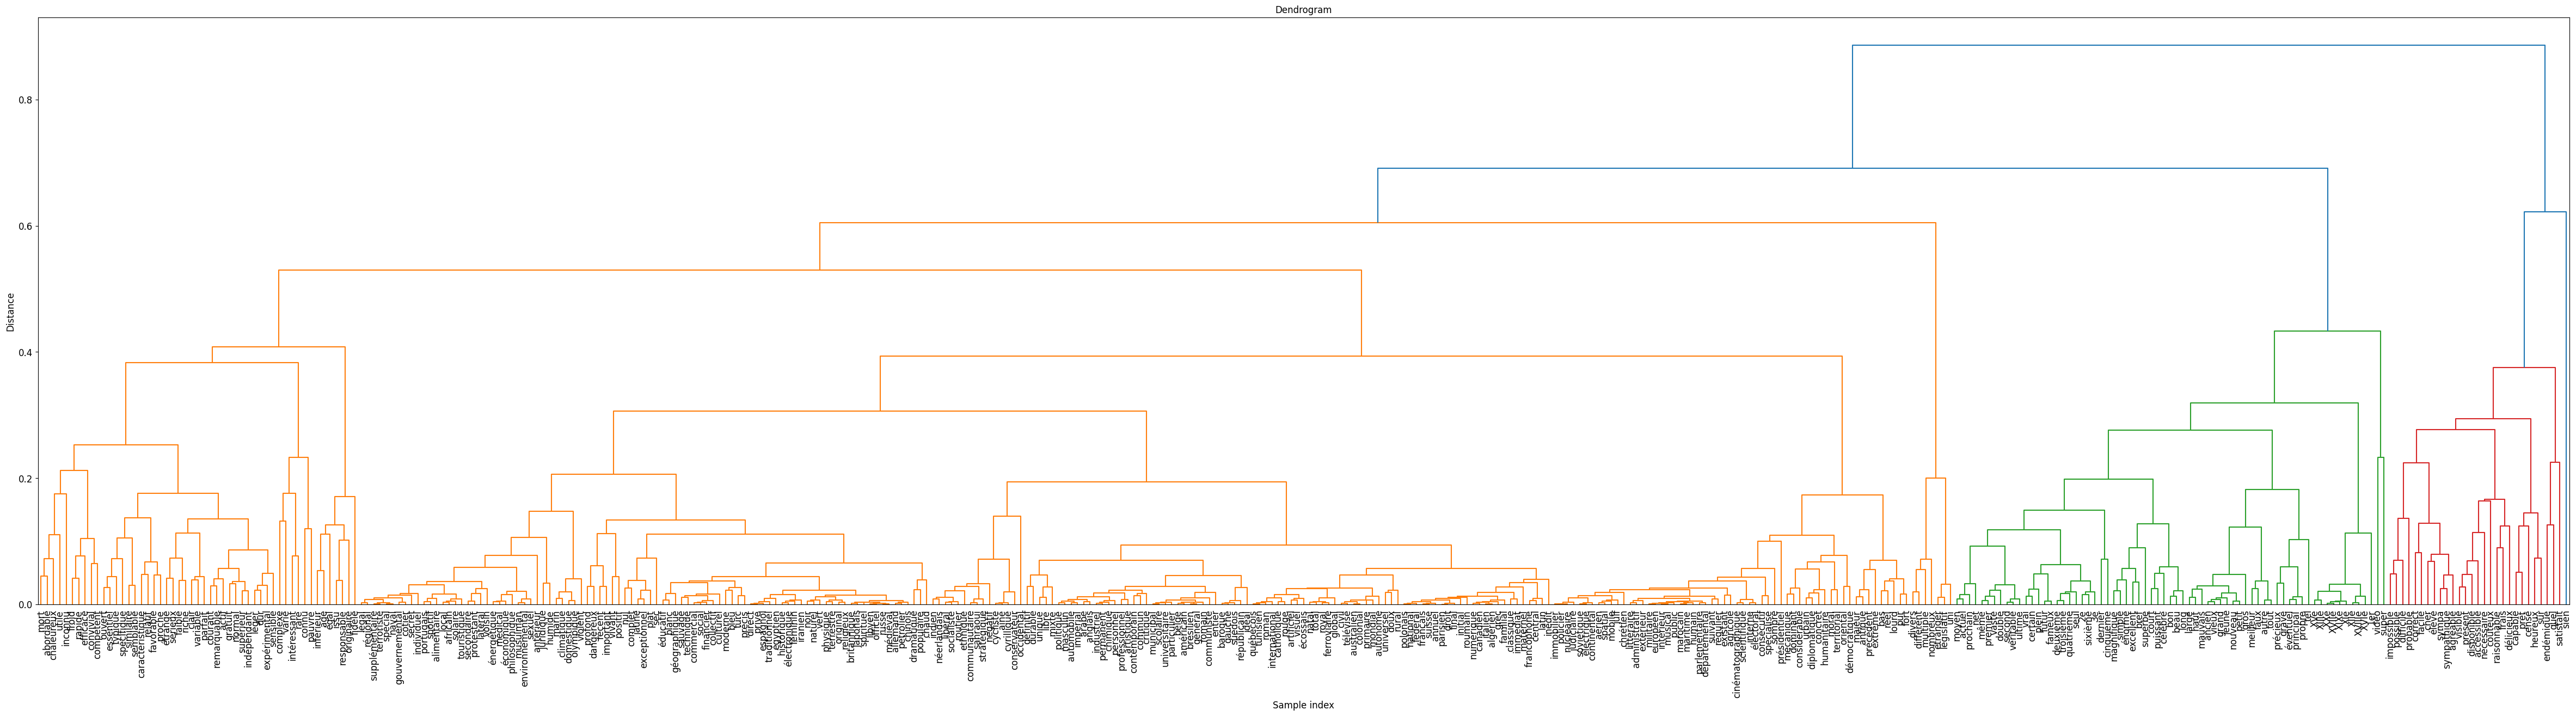

In [21]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
import matplotlib.pyplot as plt

# Hamming or jacard for categorical data, cosine for sparse matrices (normally used in NLP)
# I compute the distance for each pair of lines, each POS
distance_matrix = pdist(X, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)

plt.figure(figsize=(60, 14))

dn = dendrogram(linked,
                orientation='top',
                labels=[name for name in unique_adv],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

In [29]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

def find_optimal_clusters(X, max_clusters=20, metric='cosine', method='complete'):
    distance_matrix = pdist(X, metric=metric)
    linked = linkage(distance_matrix, method=method, optimal_ordering=True)
    
    silhouette_scores = []
    for num_clusters in range(2, max_clusters + 1):
        labels = fcluster(linked, num_clusters, criterion='maxclust')
        if len(np.unique(labels)) > 1:  # Ensure there is more than one cluster
            score = silhouette_score(X, labels, metric=metric)
            silhouette_scores.append(score)
            print(f'Number of clusters: {num_clusters}, Silhouette Score: {score}')
        else:
            silhouette_scores.append(-1)  # Append a low score if only one cluster
    
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2
    return optimal_clusters, silhouette_scores
optimal_clusters, silhouette_scores = find_optimal_clusters(X, max_clusters=50)
print(f'Optimal number of clusters: {optimal_clusters}')
print(X.shape)

Number of clusters: 2, Silhouette Score: 0.47883618753604623
Number of clusters: 3, Silhouette Score: 0.5613655367857171
Number of clusters: 4, Silhouette Score: 0.5133413437443631
Number of clusters: 5, Silhouette Score: 0.5098329324539139
Number of clusters: 6, Silhouette Score: 0.5036831360860271
Number of clusters: 7, Silhouette Score: 0.24807616814577388
Number of clusters: 8, Silhouette Score: 0.24372099500578262
Number of clusters: 9, Silhouette Score: 0.24294432887989512
Number of clusters: 10, Silhouette Score: 0.23878317572447785
Number of clusters: 11, Silhouette Score: 0.2378544542668653
Number of clusters: 12, Silhouette Score: 0.24304092522285495
Number of clusters: 13, Silhouette Score: 0.2533384136345888
Number of clusters: 14, Silhouette Score: 0.2535150457693166
Number of clusters: 15, Silhouette Score: 0.2550949420461742
Number of clusters: 16, Silhouette Score: 0.25006617710387075
Number of clusters: 17, Silhouette Score: 0.2504959358102525
Number of clusters: 18, S

In [31]:
# see what there is in each cluster
labels = fcluster(linked, optimal_clusters, criterion='maxclust')
clusters = {i: [] for i in range(1, optimal_clusters + 1)}
for i, label in enumerate(labels):
    clusters[label].append(i)

for cluster, members in clusters.items():
    print(f'Cluster {cluster}:')
    for member in members:
        print(f'  {unique_adv[member]}')

Cluster 1:
  accessible
  agréable
  capable
  censé
  cher
  correct
  coûteux
  difficile
  disponible
  délicieux
  endémique
  facile
  frais
  heureux
  impossible
  nécessaire
  possible
  probable
  présent
  prêt
  quel
  raisonnable
  satisfait
  sien
  sympa
  sympathique
  sûr
  visible
  élevé
Cluster 2:
  abordable
  actif
  administratif
  africain
  agricole
  algérien
  alimentaire
  allemand
  américain
  anglais
  annuel
  antique
  antérieur
  arabe
  artificiel
  artistique
  australien
  automobile
  autonome
  aérien
  aîné
  baroque
  bas
  belge
  blanc
  bleu
  britannique
  brésilien
  canadien
  caractéristique
  catholique
  central
  chaleureux
  chaud
  chimique
  chinois
  chrétien
  cinématographique
  civil
  clair
  classique
  climatique
  collectif
  colonial
  commercial
  commun
  communautaire
  communiste
  complet
  complexe
  compétent
  concret
  connu
  conservateur
  considérable
  consécutif
  contemporain
  continental
  convivial
  couran

In [34]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.manifold import TSNE
import plotly.express as px
import plotly.graph_objects as go

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Create a DataFrame for Plotly
df = pd.DataFrame({
    'PCA1': X_tsne[:, 0],
    'PCA2': X_tsne[:, 1],
    'Cluster': labels,
    'Word': unique_adv
})
# pca1_min, pca1_max = df['PCA1'].min(), df['PCA1'].max()
# pca2_min, pca2_max = df['PCA2'].min(), df['PCA2'].max()
# Create a scatter plot with Plotly
fig = go.Figure()

# Add traces for each cluster
for cluster in range(1, optimal_clusters + 1):
    cluster_data = df[df['Cluster'] == cluster]
    fig.add_trace(go.Scatter(
        x=cluster_data['PCA1'],
        y=cluster_data['PCA2'],
        mode='markers',
        marker=dict(size=10),
        name=f'Cluster {cluster}',
        text=cluster_data['Word'],
        hoverinfo='text'
    ))

# Update layout with dropdown menu
fig.update_layout(
    title='Word Clusters',
    xaxis_title='tsne1',
    yaxis_title='tsne2',
    width=1600,  # Set the width of the figure
    height=800,
    # xaxis=dict(range=[pca1_min, pca1_max]),
    # yaxis=dict(range=[pca2_min, pca2_max]),
    updatemenus=[
        {
            'buttons': [
                {
                    'label': 'All Clusters',
                    'method': 'update',
                    'args': [{'visible': [True] * optimal_clusters},
                             {'title': 'All Clusters'}]
                }
            ] + [
                {
                    'label': f'Cluster {i}',
                    'method': 'update',
                    'args': [{'visible': [j == i - 1 for j in range(optimal_clusters)]},
                             {'title': f'Cluster {i}'}]
                } for i in range(1, optimal_clusters + 1)
            ],
            'direction': 'down',
            'showactive': True
        }
    ]
)

fig.show()

In [35]:
fig.write_html("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/output/visualisations/GREX_adjectives_french_tsne.html")